## Fine tuning small language model
### Small llm (size < 1 billion)
### Dataset : foodexpert-1k
### Trainer : SFTTrainer (Supervised Fine Tuning reinforcement learning algorithm)
### LLM : Gemma3-270m-it

In [ ]:
! pip install gradio

In [ ]:
! pip install --upgrade git+https://github.com/huggingface/trl.git

  Cloning https://github.com/huggingface/trl.git to /tmp/pip-req-build-476filbv
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/trl.git /tmp/pip-req-build-476filbv
  Resolved https://github.com/huggingface/trl.git to commit 2fc06c8cdcb6c117c506bdf8d10b1eecd1954ef8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.7 MB/s eta 0:00:00
  Created wheel for trl: filename=trl-1.6.0.dev0-py3-none-any.whl size=763991 sha256=9dc295582be1a5ca637621f4c8d3d45f1014b77dab49f8ad9bdc4f83d60376e0
  Stored in directory: /tmp/pip-ephem-wheel-cache-82s_0ado/wheels/0e/8f/95/dfd1c9271445f7e7e2fcfd9dfdcc8fabf9adc68edd4f2ea5fd
Successfully built trl
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarro

In [ ]:
## importing libraries
import transformers
import torch
# import gradio as gr
import datasets
import trl
import accelerate
print("[INFO] transformers version :",transformers.__version__)
# print("[INFO] gradio version :",gr.__version__)
print("[INFO] torch version :",torch.__version__)
print("[INFO] datasets version :",datasets.__version__)
print("[INFO] trl version :",trl.__version__)
print("[INFO] accelerate version :",accelerate.__version__)

[INFO] transformers version : 5.0.0
[INFO] torch version : 2.11.0+cu128
[INFO] datasets version : 4.0.0
[INFO] trl version : 1.6.0.dev0
[INFO] accelerate version : 1.13.0


In [ ]:
## checking the available vram
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print('[INFO] DEVICE :',device)
if "cuda" in device :
  ## total memory allocated and the vram
  print(f"[INFO] Allocated memory: {torch.cuda.memory_allocated()} bytes")
  print(f'[INFO] Memory reserved in GB :{torch.cuda.memory_allocated()/ 1e9:.2f} GB')
  print(f"[INFO] Reserved memory: {torch.cuda.memory_reserved()} bytes")
  print(f'[INFO] Memory allocated in GB :{torch.cuda.memory_reserved()/ 1e9:.2f} GB')
elif "mps" in device:
  print(f"[INFO] Allocated memory: {torch.mps.current_allocated_memory()} bytes")
  print(f"[INFO] Reserved memory: {torch.mps.current_reserved_memory()} bytes")
  print(f"[INFO] Driver allocated memory: {torch.mps.driver_allocated_memory()} bytes")
else:
  print("[INFO] No GPU available")

[INFO] DEVICE : cuda
[INFO] Allocated memory: 0 bytes
[INFO] Memory reserved in GB :0.00 GB
[INFO] Reserved memory: 0 bytes
[INFO] Memory allocated in GB :0.00 GB


In [ ]:
## lodaing the model
from transformers import AutoModelForCausalLM , AutoTokenizer

MODEL_NAME = 'google/gemma-3-270m-it'

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto", # Changed from torch.float16 to torch.float32 for CPU compatibility
    device_map="auto",
    attn_implementation = "sdpa" # scaled dot product attention
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print('[INFO] Model name :',MODEL_NAME)
print('[INFO] MODEL',model)

config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

[INFO] Model name : google/gemma-3-270m-it
[INFO] MODEL Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear(in_features=640, out_features=256, bias=False)
          (v_proj): Linear(in_features=640, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear(in_features=2048, out_features=640, bias=False)
          (act_fn): GELUTanh()
        )
   

In [ ]:
## loading dataset
from datasets import load_dataset
dataset = load_dataset("mrdbourke/FoodExtract-1k")

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/616k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1420 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view'],
        num_rows: 1420
    })
})

In [ ]:
## lets take look on one sample
dataset["train"][42]

{'sequence': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
 'image_url': 'https://portforward.com/games/walkthroughs/The-Legend-of-Zelda-The-Wind-Waker/The-Legend-of-Zelda-The-Wind-Waker-large-430.jpg',
 'class_label': 'not_food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 156.0,
 'word_count': 28.0,
 'syn_or_real': 'real',
 'uuid': 'bbac79ce-df1f-48b8-891c-752809be11c7',
 'gpt-oss-120b-label': "{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None}

### Okay to what this project is doing
#### Input text :
***
A mouth-watering photograph captures a delectable dish centered on a rectangular white porcelain plate, resting on a rustic wooden tabletop indoors. In the background, a wooden cutting board with a long handle subtly enhances the setting. The plate is adorned with several generously-sized, cheese-stuffed peppers that have been roasted to perfection, their blistered skins marked by charred black spots. Split down the middle, the peppers reveal a creamy white cheese filling, enriched with a blend of aromatic herbs. Once stuffed, the peppers have been closed and roasted, achieving a luscious, smoky flavor.

The dish is elegantly garnished with vibrant cherry tomato halves, freshly chopped green herbs, and delicate sprinkles of small diced red onions. A light, possibly citrus-infused dressing, hinted by a sheen of oil or lime juice, gently coats the ensemble, adding an extra layer of freshness. The meticulous presentation and vivid colors make this image not only a feast for the stomach but also a feast for the eyes.

***

#### Example full sample :    
```python
{'sequence': 'A mouth-watering photograph captures a delectable dish centered on a rectangular white porcelain plate, resting on a rustic wooden tabletop indoors. In the background, a wooden cutting board with a long handle subtly enhances the setting. The plate is adorned with several generously-sized, cheese-stuffed peppers that have been roasted to perfection, their blistered skins marked by charred black spots. Split down the middle, the peppers reveal a creamy white cheese filling, enriched with a blend of aromatic herbs. Once stuffed, the peppers have been closed and roasted, achieving a luscious, smoky flavor.

The dish is elegantly garnished with vibrant cherry tomato halves, freshly chopped green herbs, and delicate sprinkles of small diced red onions. A light, possibly citrus-infused dressing, hinted by a sheen of oil or lime juice, gently coats the ensemble, adding an extra layer of freshness. The meticulous presentation and vivid colors make this image not only a feast for the stomach but also a feast for the eyes.',
 'image_url': 'http://i.imgur.com/X7cM9Df.jpg',
 'class_label': 'food',
 'source': 'pixmo_cap_dataset',
 'char_len': 1028,
 'word_count': 160,
 'syn_or_real': 'real',
 'uuid': '6720d6e0-5912-41e7-be50-85a2b63bfef9',
 'gpt-oss-120b-label': {'is_food_or_drink': True,
  'tags': ['fi', 'fa'],
  'food_items': ['cheese-stuffed peppers',
   'cherry tomato halves',
   'green herbs',
   'diced red onions',
   'citrus-infused dressing',
   'oil',
   'lime juice',
   'cheese'],
  'drink_items': []},
 'gpt-oss-120b-label-condensed': 'food_or_drink: 1
tags: fi, fa
foods: cheese-stuffed peppers, cherry tomato halves, green herbs, diced red onions, citrus-infused dressing, oil, lime juice, cheese
drinks:'}

```
#### Structures output (JSON):   
``` python
{'is_food_or_drink': True,
  'tags': ['fi', 'fa'],
  'food_items': ['cheese-stuffed peppers',
   'cherry tomato halves',
   'green herbs',
   'diced red onions',
   'citrus-infused dressing',
   'oil',
   'lime juice',
   'cheese'],
  'drink_items': []}
```
(YAML) -> to reduce token generation usage
``` yaml
food_or_drink: 1
tags: fi, fa
foods: cheese-stuffed peppers, cherry tomato halves, green herbs, diced red onions, citrus-infused dressing, oil, lime juice, cheese
drinks:
```
#### So model just wnat to take the raw input text and convert into structured output what just take the food info from text and if not any thing in test then return blank

### Tags for dictonary mapping
``` python
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertisement',
 'fp': 'food_packaging'}
```

In [ ]:
# tags for mapping

tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertisement',
 'fp': 'food_packaging'}

In [ ]:
### creating and random sample
import random

def create_random_index(dataset):
  rand_idx = random.randint(0,len(dataset)-1)
  return rand_idx

random_index = create_random_index(dataset["train"])
raw_input = dataset["train"][random_index]["sequence"]
label_output = dataset["train"][random_index]["gpt-oss-120b-label"]
condensed_output = dataset["train"][random_index]["gpt-oss-120b-label-condensed"]
print(f'[INFO] random index:{random_index}')
print(f'[INFO] raw input:\n{raw_input}\n')
print(f'[INFO] label output:\n{label_output}\n')
print(f'[INFO] condensed output:\n{condensed_output}\n')

[INFO] random index:1307
[INFO] raw input:
This composite image consists of four photographs arranged in a grid, showcasing various views of the same gray and black Corsair keyboard. The top-left image provides a close, top-down view featuring the F11, F12, Print Screen, and volume control buttons. The adjacent top-right image displays a close-up of a unique button with a raised red 3D plus sign, which may function akin to a joystick or a special input device. The bottom-left photograph highlights the Corsair logo and presents a front view encompassing keys from the middle of the space bar to the F10 key. The final bottom-right image gives an angled left-to-right perspective of the keyboard with jagged edges, possibly edited in Photoshop, and reveals a cable extending from the back. The black background creates the illusion of the keyboard floating in mid-air, emphasizing the keyboard's vintage design with large, raised keys and white lettering.

[INFO] label output:
{'is_food_or_drink

In [ ]:
## prmompt format : # Conversational prompt-completion
## {"prompt": [{"role": "user", "content": "What color is the sky?"}],
## "completion": [{"role": "assistant", "content": "It is blue."}]}

def Conversational_prompt(sample):
  prompt = {
      "prompt":[{
          "role":"user",
          "content":sample["sequence"]
      }],
      "completion":[{
          "role":"assistant",
          "content":sample["gpt-oss-120b-label-condensed"]
      }]
  }
  return prompt

random_sample = dataset["train"][random_index]
random_completed_sample = Conversational_prompt(random_sample)
print(f'[INFO] random completed sample:\n{random_completed_sample}\n')

[INFO] random completed sample:
{'prompt': [{'role': 'user', 'content': "This composite image consists of four photographs arranged in a grid, showcasing various views of the same gray and black Corsair keyboard. The top-left image provides a close, top-down view featuring the F11, F12, Print Screen, and volume control buttons. The adjacent top-right image displays a close-up of a unique button with a raised red 3D plus sign, which may function akin to a joystick or a special input device. The bottom-left photograph highlights the Corsair logo and presents a front view encompassing keys from the middle of the space bar to the F10 key. The final bottom-right image gives an angled left-to-right perspective of the keyboard with jagged edges, possibly edited in Photoshop, and reveals a cable extending from the back. The black background creates the illusion of the keyboard floating in mid-air, emphasizing the keyboard's vintage design with large, raised keys and white lettering."}], 'compl

In [ ]:
dataset = dataset.map(Conversational_prompt,batched=False)
dataset

Map:   0%|          | 0/1420 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 1420
    })
})

In [ ]:
dataset["train"][42]

{'sequence': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
 'image_url': 'https://portforward.com/games/walkthroughs/The-Legend-of-Zelda-The-Wind-Waker/The-Legend-of-Zelda-The-Wind-Waker-large-430.jpg',
 'class_label': 'not_food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 156.0,
 'word_count': 28.0,
 'syn_or_real': 'real',
 'uuid': 'bbac79ce-df1f-48b8-891c-752809be11c7',
 'gpt-oss-120b-label': "{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'content': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
   'role': 'use

In [ ]:
## creating train test split

dataset = dataset["train"].train_test_split(test_size = 0.2,shuffle=True,seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 1136
    })
    test: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 284
    })
})

#### Below is the test code for checking the pipeline

In [ ]:
## creating and message format to test transformer pipeline

def create_sample_message(input):
  return {"role":"user","content":input}

sample_message = create_sample_message("hello this is rahul kate !!")
print(f'[INFO] sample message:\n{sample_message}\n')

[INFO] sample message:
{'role': 'user', 'content': 'hello this is rahul kate !!'}



In [ ]:
from transformers import pipeline
print(f"[INFO] Creating pipeline with model: {MODEL_NAME}\n")
pipe = pipeline(task="text-generation",model=model,tokenizer=tokenizer)

[INFO] Creating pipeline with model: google/gemma-3-270m-it



In [ ]:
input_text = "Hi my name is rahul. Please reply to me with a machine learning poem."
print(f"[INFO] This is the raw text input:\n{input_text}\n")

[INFO] This is the raw text input:
Hi my name is rahul. Please reply to me with a machine learning poem.



In [ ]:
easy_sample = create_sample_message(input_text)
input_prompt = pipe.tokenizer.apply_chat_template([easy_sample], # pipeline tokenizer wants a list of inputs
                                                  tokenize=False,
                                                  add_generation_prompt=True)
print(input_prompt)

<bos><start_of_turn>user
Hi my name is rahul. Please reply to me with a machine learning poem.<end_of_turn>
<start_of_turn>model



In [ ]:
output = pipe(input_prompt,max_new_tokens=512,disable_compile=True)
print(f"[INFO] This is the input prompt: {input_prompt}")
print(f"[INFO] Output from {MODEL_NAME}:")
print(output[0]["generated_text"][len(input_prompt):]) # just because the len(input_prompt) is added first

Passing `generation_config` together with generation-related arguments=({'disable_compile', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] This is the input prompt: <bos><start_of_turn>user
Hi my name is rahul. Please reply to me with a machine learning poem.<end_of_turn>
<start_of_turn>model

[INFO] Output from google/gemma-3-270m-it:
Hi Rahul,
Your name is rahul.



In [ ]:
output

[{'generated_text': "<bos><start_of_turn>user\nHi my name is rahul. Please reply to me with a machine learning poem.<end_of_turn>\n<start_of_turn>model\nHi Rahul,\n\nI'm looking for a machine learning poem. I'm looking for something that evokes a feeling of calm and contemplation.\n"}]

#### Test complete

In [ ]:
# Get a random sample
random_idx = create_random_index(dataset["train"])
random_train_sample = dataset["train"][random_idx]
raw_text_input = random_train_sample["sequence"]

# Apply the chat template
input_prompt = pipe.tokenizer.apply_chat_template(conversation=random_train_sample["prompt"],
                                                  tokenize=False,
                                                  add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = pipe(text_inputs=input_prompt, max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Input (raw text):\n{raw_text_input}\n")
print(f"[INFO] Input (prompt formatted):\n{input_prompt}\n")
print(f"[INFO] Output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}")

# as this is not good as model dosent know what to do

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Input (raw text):
Fruity Pouch Fruit Puree Tropical - Ingredients: Apple (74%), Mango (15%), Pineapple Puree (5%), Apple Juice Concentrate (5%), Acidity Regulators (Ascorbic Acid, Citric Acid), Natural Mango Flavour, Natural Pineapple Flavour. Barcode: 9 349763 000638.

[INFO] Input (prompt formatted):
<bos><start_of_turn>user
Fruity Pouch Fruit Puree Tropical - Ingredients: Apple (74%), Mango (15%), Pineapple Puree (5%), Apple Juice Concentrate (5%), Acidity Regulators (Ascorbic Acid, Citric Acid), Natural Mango Flavour, Natural Pineapple Flavour. Barcode: 9 349763 000638.<end_of_turn>
<start_of_turn>model


[INFO] Output:
Okay, I understand. I am ready to process the information you provided. Please provide me with the fruit puree and the ingredients. I will then process it and provide you with the fruit puree, mango puree, pineapple puree, and apple juice concentrate.


In [ ]:
## Lets modify the prompt
prompt_instruction = """Given the following target input text from an image caption, please extract the food and drink items to a list.
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: <targ_input_text>"""

In [ ]:
def update_input_message_content(input):
  original_content = input["prompt"][0]["content"] # the original message
  updated_content = prompt_instruction.replace("<targ_input_text>",original_content)
  new_prompt = [{
      "role":"user",
      "content":updated_content
  }]
  return new_prompt

print(f'[INFO] Original content:\n{random_train_sample["prompt"][0]["content"]}')
print()
print(f'[INFO] New content with instructions in prompt:')
print(update_input_message_content(input=random_train_sample)[0]["content"])

[INFO] Original content:
Fruity Pouch Fruit Puree Tropical - Ingredients: Apple (74%), Mango (15%), Pineapple Puree (5%), Apple Juice Concentrate (5%), Acidity Regulators (Ascorbic Acid, Citric Acid), Natural Mango Flavour, Natural Pineapple Flavour. Barcode: 9 349763 000638.

[INFO] New content with instructions in prompt:
Given the following target input text from an image caption, please extract the food and drink items to a list.
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target i

In [ ]:
prompt = update_input_message_content(input=random_train_sample)
prompt = pipe.tokenizer.apply_chat_template(conversation = [prompt],add_generation_prompt=True,tokenize=False)
prompt
defaults_output = pipe(text_inputs=prompt,max_new_tokens=512)


Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
print('[INFO] Outputs:\n',defaults_output[0][0]["generated_text"][len(prompt):])

[INFO] Outputs:
 bos><start_of_turn>user
Given the following target input text from an image caption, please extract the food and drink items to a list.
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: Fruity Pouch Fruit Puree Tropical - Ingredients: Apple (74%), Mango (15%), Pineapple Puree (5%), Apple Juice Concentrate (5%), Acidity Regulators (Ascorbic Acid, Citric Acid), Natural Mango Flavour, Natural Pineapple Flavour. Barcode: 9 349763 000638.<end_of_turn>
<start_of

### Poor

In [ ]:
dataset["train"][42]

{'sequence': '12. Single Family Homes at 10 Vandiver Lane Town And Country, Missouri 63131 United States',
 'image_url': 'https://www.dielmannsothebysrealty.com/localimagereader.ashx?imageurl=https%3A%2F%2Fmatrixrets.marismatrix.com%2FRets%2FGetRetsMedia.ashx%3FKey%3D80260947%26TableID%3D5%26Type%3D1%26Number%3D11%26Size%3D5%26usd%3D-1%26ust%3Dmv4EAD2pUz8nPKQYIaLTB5JoKsV11RGiYmUGgqKqIlUIq43ONsdHHw))&imagecache=true',
 'class_label': 'not_food',
 'source': 'coyo700m_dataset',
 'char_len': 90.0,
 'word_count': 15.0,
 'syn_or_real': 'real',
 'uuid': '45e78048-bc1d-4826-a184-c823d66149de',
 'gpt-oss-120b-label': "{'is_food_or_drink': False, 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'role': 'user',
   'content': '12. Single Family Homes at 10 Vandiver Lane Town And Count

## Fine-tuning our model

  Cloning https://github.com/huggingface/trl.git to /tmp/pip-req-build-68m0nvpy
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/trl.git /tmp/pip-req-build-68m0nvpy
  Resolved https://github.com/huggingface/trl.git to commit 78776953c1c49253787ea04c23e9390ffd14fe02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for trl: filename=trl-1.5.0.dev0-py3-none-any.whl size=754667 sha256=724c4a25cd2e07252386db6791a058aa0225be1bba422c5c776d1986f3b66e89
  Stored in directory: /tmp/pip-ephem-wheel-cache-w81giagc/wheels/0e/8f/95/dfd1c9271445f7e7e2fcfd9dfdcc8fabf9adc68edd4f2ea5fd
Successfully built trl
  Attempting uninstall: trl
    Found existing installation: trl 1.4.0
    Uninstalling trl-1.4.0:
      Successfully uninstalled trl-1.4.0


In [ ]:
from trl import SFTConfig,SFTTrainer

In [ ]:
dtype = model.dtype
MODEL_DIR = './checkpoints'
BATCH_EVAL = 2
BATCH_TRAIN = 2
LEARNING_RATE = 1e-2
print('[INFO] Dtype:',dtype)
print('[INFO] Base leanring rate',LEARNING_RATE)
print('[INFO] Model dir:',MODEL_DIR)

[INFO] Dtype: torch.bfloat16
[INFO] Base leanring rate 0.01
[INFO] Model dir: ./checkpoints


In [ ]:
sft_config = SFTConfig(
    output_dir = MODEL_DIR,
    per_device_train_batch_size = BATCH_TRAIN,
    per_device_eval_batch_size = BATCH_EVAL,
    num_train_epochs = 3,
    do_eval = True,
    learning_rate = LEARNING_RATE,
    optim = "adamw_torch_fused",
    completion_only_loss = True,
    gradient_checkpointing = False,
    logging_steps = 1,
    save_strategy = "epoch",
    eval_strategy = "epoch",
    max_length = 1024,
    packing = False,
    fp16 = (dtype == torch.float16),
    bf16 = (dtype == torch.bfloat16),
    lr_scheduler_type = "constant",
    load_best_model_at_end = True,
    metric_for_best_model="mean_token_accuracy",
    greater_is_better=True,
    push_to_hub = False,
    report_to = "none"
)

In [ ]:
trainer = SFTTrainer(
    model = model,
    train_dataset = dataset["train"],
    eval_dataset = dataset["test"],
    args = sft_config
)

Tokenizing train dataset:   0%|          | 0/1136 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/284 [00:00<?, ? examples/s]

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2, 'pad_token_id': 0}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.832657,1.693504,1.385050,176257.000000,0.786714
2,0.006452,1.765799,1.200469,352514.000000,0.778286
3,0.068659,1.524445,0.827618,528771.000000,0.803362


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


TrainOutput(global_step=1704, training_loss=2.4243292255972584, metrics={'train_runtime': 1011.6871, 'train_samples_per_second': 3.369, 'train_steps_per_second': 1.684, 'total_flos': 466070526888960.0, 'train_loss': 2.4243292255972584, 'epoch': 3.0})

In [ ]:
# Save the model
trainer.save_model()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
## evaluating the sft trainer
eval_metrics = trainer.evaluate()
print('[INFO] Evaluate metrics')
eval_metrics

[INFO] Evaluate metrics


{'eval_loss': 1.5244454145431519,
 'eval_runtime': 26.1919,
 'eval_samples_per_second': 10.843,
 'eval_steps_per_second': 5.422,
 'eval_entropy': 0.8276180704452203,
 'eval_num_tokens': 528771.0,
 'eval_mean_token_accuracy': 0.8033624480307942,
 'epoch': 3.0}

In [ ]:
# checking some plots
import matplotlib.pyplot as plt
log_history = trainer.state.log_history

In [ ]:
train_losses = [x['loss'] for x in log_history if "loss" in x]
eval_losses = [x["eval_loss"] for x in log_history if "eval_loss" in x ]
train_epoch = [x["epoch"] for x in log_history if "loss" in x]
eval_epoch = [x["epoch"] for x in log_history if "eval_loss" in x]

In [ ]:
log_history.__len__()

1709

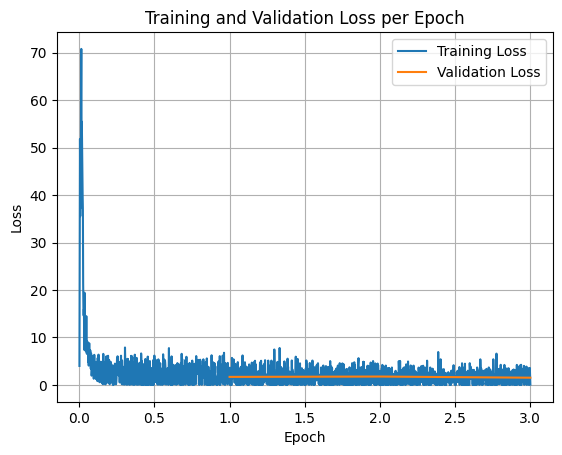

In [ ]:
# Plot the training loss
plt.plot(train_epoch, train_losses, label="Training Loss")
plt.plot(eval_epoch, eval_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
!ls /content/checkpoints

chat_template.jinja  config.json	     tokenizer_config.json
checkpoint-1136      generation_config.json  tokenizer.json
checkpoint-1704      model.safetensors	     training_args.bin
checkpoint-568	     README.md


In [ ]:
# Optional: Remove all the checkpoint folders (since we've already saved the best model)
!rm -rf /content/checkpoints/checkpoint-*/*
!rm -rf /content/checkpoints/checkpoint-*

In [ ]:
!ls /content/checkpoints

chat_template.jinja	model.safetensors      tokenizer.json
config.json		README.md	       training_args.bin
generation_config.json	tokenizer_config.json


## testing phase : from model check point

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
checkpoint_dir = "/content/checkpoints"
print('[INFO] Model Path name :',checkpoint_dir)

[INFO] Model Path name : /content/checkpoints


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForCausalLM.from_pretrained(checkpoint_dir,dtype="auto",attn_implementation="sdpa",device_map="auto")

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

In [ ]:
from transformers import pipeline
loaded_model_pipeline = pipeline("text-generation",model=model,tokenizer=tokenizer)
loaded_model_pipeline

TextGenerationPipeline: {'model': 'Gemma3ForCausalLM', 'dtype': 'bfloat16', 'device': 'cuda', 'input_modalities': ('image', 'text'), 'output_modalities': ('text',)}

In [ ]:
# Get a random sample
import random

random_test_idx = random.randint(0, len(dataset["test"])-1)
random_test_sample = dataset["test"][random_test_idx]

# Apply the chat template
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=random_test_sample["prompt"],
                                                                    tokenize=False,
                                                                    add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = loaded_model_pipeline(text_inputs=input_prompt,
                                        max_new_tokens=256)

# View and compare the outputs
print(f"[INFO] Test sample input:\n{input_prompt}\n")
print(f"[INFO] Fine-tuned model output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}\n")
print(f"[INFO] Test label (ideal output):\n{random_test_sample['gpt-oss-120b-label-condensed']}")

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Test sample input:
<bos><start_of_turn>user
9G<end_of_turn>
<start_of_turn>model


[INFO] Fine-tuned model output:
food_or_drink: 0
tags: 
foods: 
drinks:

[INFO] Test label (ideal output):
food_or_drink: 0
tags: 
foods: 
drinks:


In [ ]:
dataset["train"][2]

{'sequence': "The image showcases a delectable chocolate pie adorned with a tantalizing array of crushed candies and confections. Atop the pie, a medley of ingredients creates a visual feast, featuring a mix of peanut and chocolate clusters, broken pretzel bits, and generous chunks of caramel. Pieces of Reese's Peanut Butter Cups are scattered across the pie, adding to the indulgent toppings. A rich fudge drizzle cascades over the surface and sides of the pie, creating a luscious, glossy finish, with some areas oozing slightly over the exposed pie crust edges.\n\nThe pie rests upon a clear plastic cutting mat, which itself is placed on a white-textured countertop that hints at a cozy kitchenette setting. In the background, several chairs encircle what appears to be a dining table, suggesting a gathering where this sumptuous chocolate pie will soon be served. The anticipation of slicing into this generously topped dessert and sharing it among friends or family completes the inviting and

In [ ]:
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(
    conversation = dataset["train"][2]["prompt"],
    tokenize = False,
    add_generation_prompt = True
)
print("[INFO] Input prompt for sample 2:\n",input_prompt)

[INFO] Input prompt for sample 2:
 <bos><start_of_turn>user
The image showcases a delectable chocolate pie adorned with a tantalizing array of crushed candies and confections. Atop the pie, a medley of ingredients creates a visual feast, featuring a mix of peanut and chocolate clusters, broken pretzel bits, and generous chunks of caramel. Pieces of Reese's Peanut Butter Cups are scattered across the pie, adding to the indulgent toppings. A rich fudge drizzle cascades over the surface and sides of the pie, creating a luscious, glossy finish, with some areas oozing slightly over the exposed pie crust edges.

The pie rests upon a clear plastic cutting mat, which itself is placed on a white-textured countertop that hints at a cozy kitchenette setting. In the background, several chairs encircle what appears to be a dining table, suggesting a gathering where this sumptuous chocolate pie will soon be served. The anticipation of slicing into this generously topped dessert and sharing it among 

In [ ]:
dataset["train"][2]["gpt-oss-120b-label-condensed"]

"food_or_drink: 1\ntags: fi\nfoods: chocolate pie, crushed candies, peanut clusters, chocolate clusters, pretzel bits, caramel, Reese's Peanut Butter Cups, fudge drizzle\ndrinks:"

In [ ]:
outputs = loaded_model_pipeline(text_inputs=input_prompt,max_new_tokens=512)

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [ ]:
# View and compare the outputs
print(f"[INFO] Test sample input:\n{input_prompt}\n")
print(f"[INFO] Fine-tuned model output:\n{outputs[0]['generated_text'][len(input_prompt):]}\n")
print(f"[INFO] Test label (ideal output):\n{dataset["train"][2]['gpt-oss-120b-label-condensed']}")

[INFO] Test sample input:
<bos><start_of_turn>user
The image showcases a delectable chocolate pie adorned with a tantalizing array of crushed candies and confections. Atop the pie, a medley of ingredients creates a visual feast, featuring a mix of peanut and chocolate clusters, broken pretzel bits, and generous chunks of caramel. Pieces of Reese's Peanut Butter Cups are scattered across the pie, adding to the indulgent toppings. A rich fudge drizzle cascades over the surface and sides of the pie, creating a luscious, glossy finish, with some areas oozing slightly over the exposed pie crust edges.

The pie rests upon a clear plastic cutting mat, which itself is placed on a white-textured countertop that hints at a cozy kitchenette setting. In the background, several chairs encircle what appears to be a dining table, suggesting a gathering where this sumptuous chocolate pie will soon be served. The anticipation of slicing into this generously topped dessert and sharing it among friends o

In [ ]:
## pushing model to hugging face
hf_token = "hf_*****************"

from huggingface_hub import HfApi, create_repo
api = HfApi()

In [ ]:
HF_USERNAME = "RahulKate-173"

# Create the repo (this is in the format [Hugging Face Username]/[Target Model Name])
repo_id = f"{HF_USERNAME}/FoodExtract-gemma-3-270m-fine-tune-v1"

# Create the repo
create_repo(repo_id,
            repo_type="model",
            private=False, # optionally make the repo private if you'd like to upload sensitive information
            exist_ok=True,
            token=hf_token)

RepoUrl('https://huggingface.co/RahulKate-173/FoodExtract-gemma-3-270m-fine-tune-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='RahulKate-173/FoodExtract-gemma-3-270m-fine-tune-v1')

In [ ]:
# Upload the entire model folder containing our model files and README.md
print(f"[INFO] Uploading checkpoint directory: {checkpoint_dir} to Hugging Face repo: {repo_id}")
api.upload_folder(
    folder_path="/content/checkpoints",
    repo_id=repo_id,
    repo_type="model",
    token=hf_token
)

[INFO] Uploading checkpoint directory: /content/checkpoints to Hugging Face repo: RahulKate-173/FoodExtract-gemma-3-270m-fine-tune-v1


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...heckpoints/tokenizer.json:  23%|##3       | 7.69MB / 33.4MB            

  ...kpoints/model.safetensors:   0%|          |  647kB /  536MB            

  ...kpoints/training_args.bin: 100%|##########| 5.65kB / 5.65kB            

CommitInfo(commit_url='https://huggingface.co/RahulKate-173/FoodExtract-gemma-3-270m-fine-tune-v1/commit/3eb697be4bccd8ba6bd4ddc8f2d9c3c97d8419f2', commit_message='Upload folder using huggingface_hub', commit_description='', oid='3eb697be4bccd8ba6bd4ddc8f2d9c3c97d8419f2', pr_url=None, repo_url=RepoUrl('https://huggingface.co/RahulKate-173/FoodExtract-gemma-3-270m-fine-tune-v1', endpoint='https://huggingface.co', repo_type='model', repo_id='RahulKate-173/FoodExtract-gemma-3-270m-fine-tune-v1'), pr_revision=None, pr_num=None)